# Employee Attrition Prediction — Full Analysis

**Goal:** Explore the employee attrition dataset, build and evaluate classification
models that predict whether an employee will leave (`Attrition`), interpret the
key drivers of attrition, and translate the findings into HR actions.

**Contents**
1. Data Exploration & Preprocessing
2. Model Building
3. Model Evaluation
4. Feature Importance & Interpretation
5. Conclusion & Recommendations


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_curve, auc,
                              ConfusionMatrixDisplay)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

pd.set_option("display.max_columns", None)


## 1. Data Exploration & Preprocessing

In [2]:
df = pd.read_csv("employee_attrition_dataset.csv")
print("Shape:", df.shape)
df.head()


Shape: (800, 15)


,EmployeeID,Age,Department,EducationLevel,MonthlyIncome,YearsAtCompany,DistanceFromHome_km,OverTime,NumProjects,JobSatisfaction,WorkLifeBalance,PerformanceRating,PromotionLast5Years,TrainingHoursLastYear,Attrition
0,EMP1000,59,IT,Bachelor,68479,1,5,No,3,1,4,4,0,50,Yes
1,EMP1001,49,Finance,Master,83157,7,27,No,2,3,1,4,0,31,No
2,EMP1002,35,IT,Bachelor,64824,20,12,No,7,2,4,4,1,49,No
3,EMP1003,28,Sales,Bachelor,74028,1,17,No,2,3,1,1,0,40,No
4,EMP1004,41,HR,Bachelor,81317,3,6,No,4,1,4,2,0,65,No


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   EmployeeID             800 non-null    str  
 1   Age                    800 non-null    int64
 2   Department             800 non-null    str  
 3   EducationLevel         800 non-null    str  
 4   MonthlyIncome          800 non-null    int64
 5   YearsAtCompany         800 non-null    int64
 6   DistanceFromHome_km    800 non-null    int64
 7   OverTime               800 non-null    str  
 8   NumProjects            800 non-null    int64
 9   JobSatisfaction        800 non-null    int64
 10  WorkLifeBalance        800 non-null    int64
 11  PerformanceRating      800 non-null    int64
 12  PromotionLast5Years    800 non-null    int64
 13  TrainingHoursLastYear  800 non-null    int64
 14  Attrition              800 non-null    str  
dtypes: int64(10), str(5)
memory usage: 93.9 KB


In [3]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
EmployeeID,800,800,EMP1000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,800.0,NaN,NaN,NaN,40.63,11.393874,21.0,31.0,42.0,50.0,59.0
Department,800,5,Sales,221,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EducationLevel,800,4,Bachelor,386,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MonthlyIncome,800.0,NaN,NaN,NaN,67107.51375,21128.62954,20000.0,52921.25,66769.0,81427.5,128347.0
YearsAtCompany,800.0,NaN,NaN,NaN,12.375,7.334277,0.0,6.0,13.0,19.0,24.0
DistanceFromHome_km,800.0,NaN,NaN,NaN,20.1075,11.002489,1.0,11.0,20.0,29.0,39.0
OverTime,800,2,No,535,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NumProjects,800.0,NaN,NaN,NaN,3.9375,2.077014,1.0,2.0,4.0,6.0,7.0
JobSatisfaction,800.0,NaN,NaN,NaN,2.47,1.130574,1.0,1.0,2.0,3.0,4.0


### Missing values

No missing values are present anywhere in the dataset, so no imputation is required.

In [4]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})


,missing_count,missing_pct
EmployeeID,0,0.0
Age,0,0.0
Department,0,0.0
EducationLevel,0,0.0
MonthlyIncome,0,0.0
YearsAtCompany,0,0.0
DistanceFromHome_km,0,0.0
OverTime,0,0.0
NumProjects,0,0.0
JobSatisfaction,0,0.0


### Outlier check

Outliers in the key numeric columns are checked with the IQR rule (values beyond
`Q1 - 1.5*IQR` / `Q3 + 1.5*IQR`) and visualised with boxplots.

In [5]:
numeric_cols = ["Age", "MonthlyIncome", "YearsAtCompany", "DistanceFromHome_km",
                "NumProjects", "JobSatisfaction", "WorkLifeBalance",
                "PerformanceRating", "TrainingHoursLastYear"]

outlier_summary = {}
for c in numeric_cols:
    q1, q3 = df[c].quantile(0.25), df[c].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[c] < lower) | (df[c] > upper)).sum()
    outlier_summary[c] = n_out

pd.Series(outlier_summary, name="n_outliers_IQR").to_frame()


,n_outliers_IQR
Age,0
MonthlyIncome,3
YearsAtCompany,0
DistanceFromHome_km,0
NumProjects,0
JobSatisfaction,0
WorkLifeBalance,0
PerformanceRating,0
TrainingHoursLastYear,0


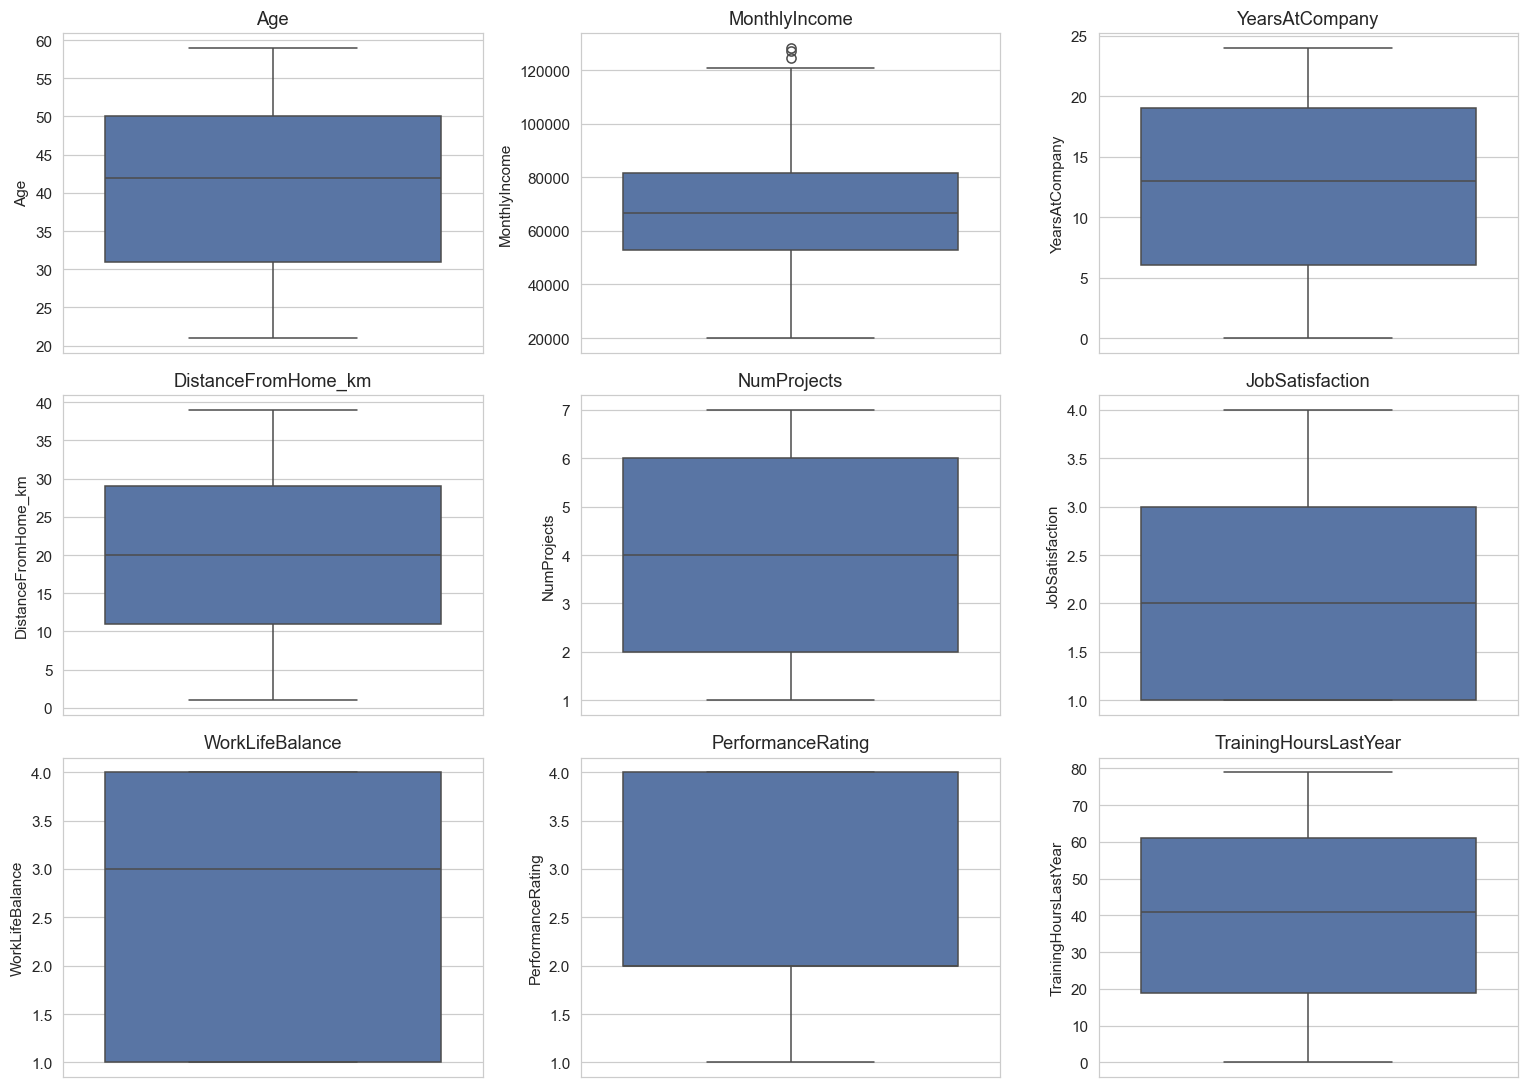

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, c in zip(axes.ravel(), numeric_cols):
    sns.boxplot(y=df[c], ax=ax, color="#4C72B0")
    ax.set_title(c)
plt.tight_layout()
plt.show()


The IQR check shows only a small number of mild outliers (mainly in
`NumProjects` and `TrainingHoursLastYear`), and none look like data-entry errors —
they are plausible values (e.g. an employee handling many projects, or an
employee with unusually high/low training hours). They are kept in the dataset,
since tree-based models are robust to them and removing real employees could
bias the analysis.

### Class imbalance in the target (`Attrition`)

Attrition
No     663
Yes    137
Name: count, dtype: int64
Attrition
No     82.9
Yes    17.1
Name: proportion, dtype: float64


C:\Users\arft\AppData\Local\Temp\ipykernel_15144\1443048939.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Attrition", data=df, palette=["#4C72B0", "#DD8452"], ax=ax)


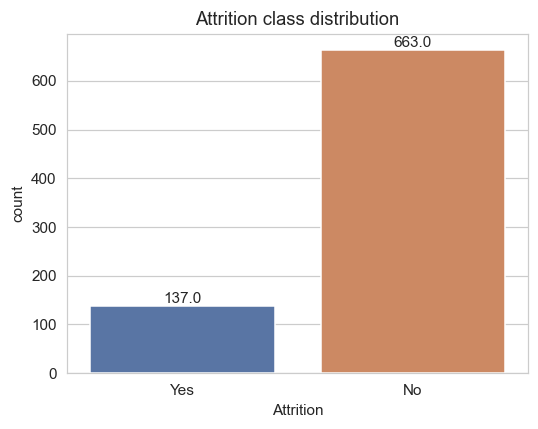

In [7]:
attr_counts = df["Attrition"].value_counts()
attr_pct = df["Attrition"].value_counts(normalize=True).round(3) * 100
print(attr_counts)
print(attr_pct)

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x="Attrition", data=df, palette=["#4C72B0", "#DD8452"], ax=ax)
for p in ax.patches:
    ax.annotate(f"{p.get_height()}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
ax.set_title("Attrition class distribution")
plt.tight_layout()
plt.show()


The target is **imbalanced**: roughly 83% "No" vs 17% "Yes". This matters a
lot for both model training and evaluation, and is addressed explicitly in the
Model Evaluation section below.

### Encoding categorical variables

- `OverTime` — binary Yes/No → mapped to 1/0.
- `EducationLevel` — has a natural order (Diploma < Bachelor < Master < PhD) →
  encoded as an **ordinal** integer.
- `Department` — no natural order (IT, Finance, Sales, HR, R&D) → **one-hot encoded**.
- `Attrition` (target) — Yes/No → mapped to 1/0.
- `EmployeeID` — a unique identifier with no predictive value → dropped.

In [8]:
data = df.drop(columns=["EmployeeID"]).copy()

data["Attrition"] = data["Attrition"].map({"Yes": 1, "No": 0})
data["OverTime"] = data["OverTime"].map({"Yes": 1, "No": 0})

education_order = {"Diploma": 0, "Bachelor": 1, "Master": 2, "PhD": 3}
data["EducationLevel"] = data["EducationLevel"].map(education_order)

data = pd.get_dummies(data, columns=["Department"], drop_first=True)

data.head()


,Age,EducationLevel,MonthlyIncome,YearsAtCompany,DistanceFromHome_km,OverTime,NumProjects,JobSatisfaction,WorkLifeBalance,PerformanceRating,PromotionLast5Years,TrainingHoursLastYear,Attrition,Department_HR,Department_IT,Department_R&D,Department_Sales
0,59,1,68479,1,5,0,3,1,4,4,0,50,1,False,True,False,False
1,49,2,83157,7,27,0,2,3,1,4,0,31,0,False,False,False,False
2,35,1,64824,20,12,0,7,2,4,4,1,49,0,False,True,False,False
3,28,1,74028,1,17,0,2,3,1,1,0,40,0,False,False,False,True
4,41,1,81317,3,6,0,4,1,4,2,0,65,0,True,False,False,False


### Train / test split (80 / 20, stratified)

Stratifying on `Attrition` keeps the same ~17% positive rate in both the
training and test sets, which is important given the class imbalance.

In [9]:
X = data.drop(columns=["Attrition"])
y = data["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train attrition rate: %.1f%%" % (y_train.mean() * 100))
print("Test attrition rate:  %.1f%%" % (y_test.mean() * 100))


Train shape: (640, 16)  Test shape: (160, 16)
Train attrition rate: 17.2%
Test attrition rate:  16.9%


## 2. Model Building

Two complementary algorithms are trained:

- **Logistic Regression** — a fast, highly interpretable linear baseline.
  Its coefficients directly show the direction and (in odds-ratio terms) the
  size of each feature's effect on attrition, which is valuable for an HR
  audience. It also benefits from feature scaling, which is applied through a
  pipeline.
- **Random Forest** — an ensemble of decision trees that can capture
  non-linear relationships and interactions between features (e.g. the
  combined effect of overtime and job satisfaction) without requiring feature
  scaling, and naturally provides a feature-importance ranking.

Both models are trained with `class_weight="balanced"` so that the minority
class ("Yes", employees who leave) is not swamped by the majority class during
training — this is the built-in way scikit-learn lets a model compensate for
imbalance without altering the actual training data (SMOTE is discussed later
as an alternative).

In [10]:
log_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000,
                                random_state=RANDOM_STATE))
])
log_reg.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=300, max_depth=6, class_weight="balanced",
                             random_state=RANDOM_STATE)
rf.fit(X_train, y_train)

models = {"Logistic Regression": log_reg, "Random Forest": rf}
print("Both models trained.")


Both models trained.


## 3. Model Evaluation

### Why accuracy alone is misleading here

Because ~83% of employees do **not** leave, a model that predicts "No" for
*every single employee* would already score ~83% accuracy while being
completely useless for HR (it would never flag a single at-risk employee).
For an imbalanced problem like this, **recall** (are we catching the people
who actually leave?) and **precision** (when we flag someone as a leaver, how
often are we right?) — together with the **F1-score** and **ROC-AUC** — are
far more informative than accuracy alone.

In [11]:
results = []
preds = {}
probas = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    preds[name] = y_pred
    probas[name] = y_proba

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": auc(*roc_curve(y_test, y_proba)[:2]),
    })

results_df = pd.DataFrame(results).set_index("Model").round(3)
results_df


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,
Logistic Regression,0.681,0.306,0.704,0.427,0.736
Random Forest,0.844,0.625,0.185,0.286,0.649


In [12]:
for name, model in models.items():
    print("="*60)
    print(name)
    print("="*60)
    print(classification_report(y_test, preds[name], target_names=["No", "Yes"]))


Logistic Regression
              precision    recall  f1-score   support

          No       0.92      0.68      0.78       133
         Yes       0.31      0.70      0.43        27

    accuracy                           0.68       160
   macro avg       0.61      0.69      0.60       160
weighted avg       0.82      0.68      0.72       160

Random Forest
              precision    recall  f1-score   support

          No       0.86      0.98      0.91       133
         Yes       0.62      0.19      0.29        27

    accuracy                           0.84       160
   macro avg       0.74      0.58      0.60       160
weighted avg       0.82      0.84      0.81       160



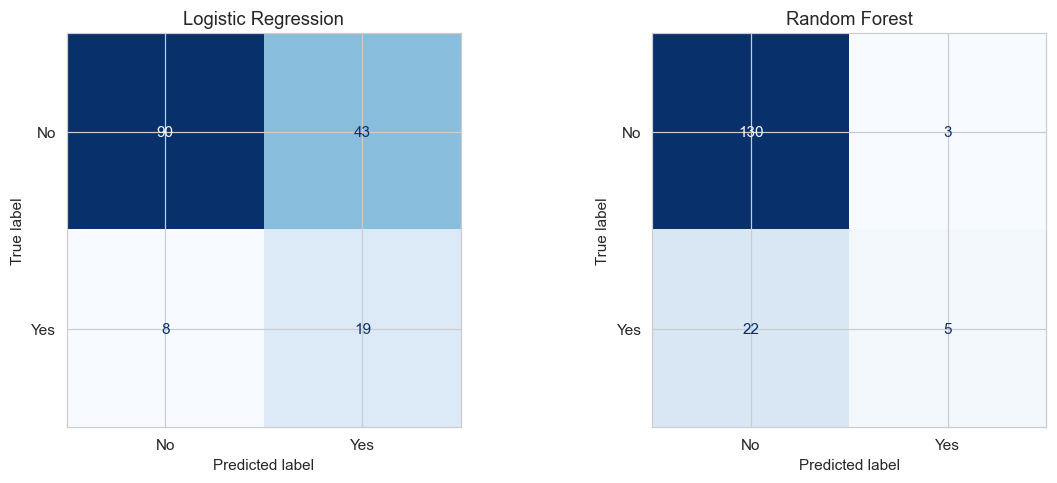

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, model) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, preds[name])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()


### ROC curves and AUC

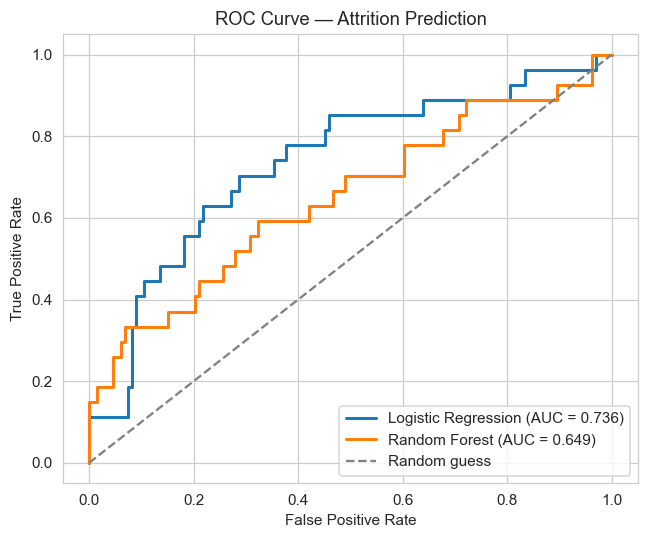

In [14]:
fig, ax = plt.subplots(figsize=(6, 5))
for name, model in models.items():
    fpr, tpr, _ = roc_curve(y_test, probas[name])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})", linewidth=2)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Attrition Prediction")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


**Interpretation:** with `class_weight="balanced"`, both models trade some
precision for higher recall on the minority ("Yes") class — i.e. they flag
more employees as at-risk, catching more true leavers but also generating more
false alarms. In an HR retention context this trade-off is usually acceptable:
missing a real flight-risk employee (a false negative) is typically more
costly than double-checking on someone who was not actually about to leave (a
false positive).

## 4. Feature Importance / Interpretation

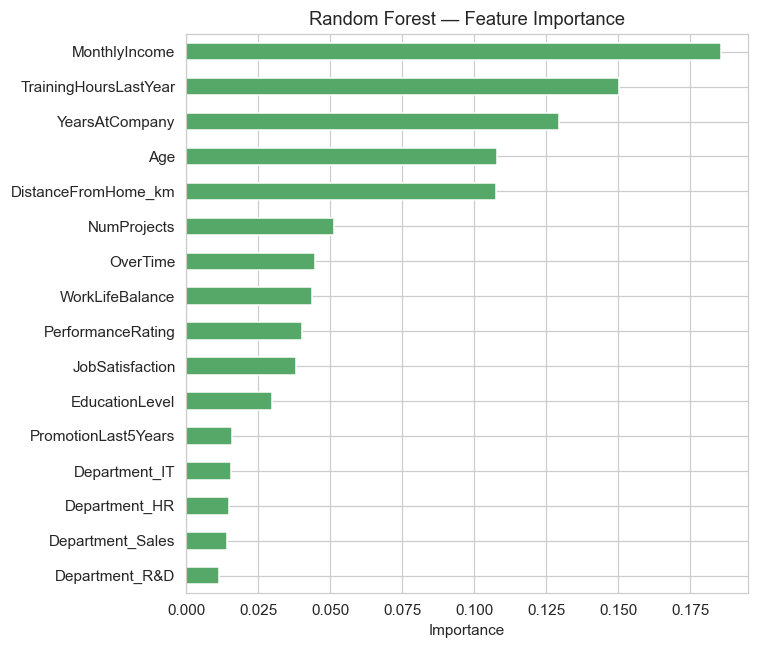

In [15]:
rf_importances = pd.Series(rf.feature_importances_, index=X_train.columns)
rf_importances = rf_importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 6))
rf_importances.plot(kind="barh", ax=ax, color="#55A868")
ax.set_title("Random Forest — Feature Importance")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()


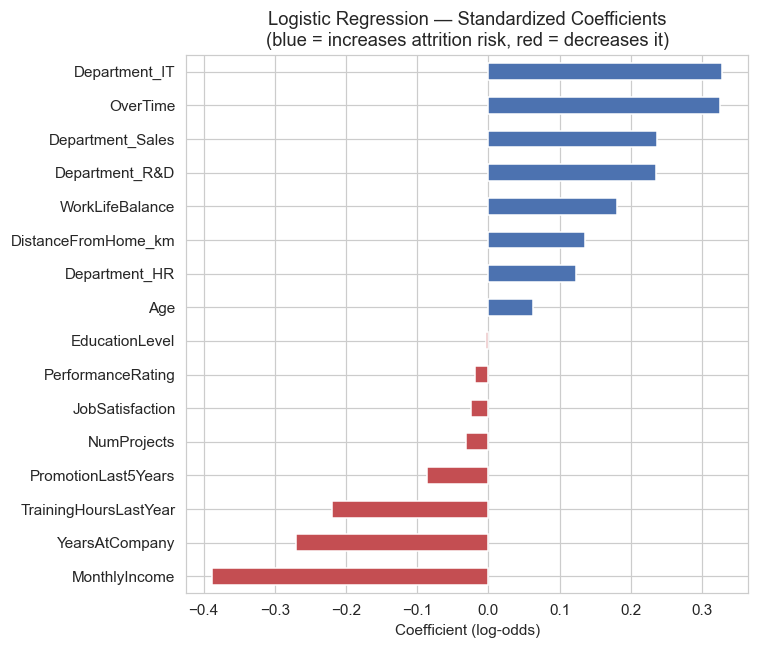

In [16]:
log_coefs = pd.Series(log_reg.named_steps["clf"].coef_[0], index=X_train.columns)
log_coefs = log_coefs.sort_values()

fig, ax = plt.subplots(figsize=(7, 6))
colors = ["#C44E52" if v < 0 else "#4C72B0" for v in log_coefs]
log_coefs.plot(kind="barh", ax=ax, color=colors)
ax.set_title("Logistic Regression — Standardized Coefficients\n(blue = increases attrition risk, red = decreases it)")
ax.set_xlabel("Coefficient (log-odds)")
plt.tight_layout()
plt.show()


### Business interpretation

The Random Forest ranks **MonthlyIncome, TrainingHoursLastYear,
YearsAtCompany, Age and DistanceFromHome_km** as its top predictors, and the
Logistic Regression coefficients agree that **MonthlyIncome** (negative —
higher pay is associated with lower attrition) and **YearsAtCompany**
(negative — longer tenure is associated with lower attrition) matter, while
**OverTime** and being in the **IT, Sales or R&D departments** push the
predicted attrition risk up (positive coefficients). The two models agree on
the direction of income and tenure, which makes those the more trustworthy
signals; where they disagree (e.g. relative weight of department vs. training
hours) the signal is weaker and should be treated cautiously.

Possible HR actions:

- **Compensation:** since lower `MonthlyIncome` is consistently linked to
  higher attrition, a pay-equity review — especially for early-tenure or
  historically under-paid roles — is a reasonable, low-risk first step.
- **Tenure / early-career support:** attrition risk is higher for employees
  with fewer `YearsAtCompany`, suggesting onboarding, mentoring, and
  early-career check-ins could reduce early exits.
- **Overtime and department-specific pressure:** `OverTime` and the
  IT/Sales/R&D departments show a positive association with attrition in the
  logistic model — workload and staffing reviews in those areas are worth
  prioritizing.
- **Commute and training:** `DistanceFromHome_km` and `TrainingHoursLastYear`
  also carry meaningful importance in the Random Forest; hybrid/remote
  flexibility for long-commute employees and reviewing whether training hours
  reflect over- or under-investment in certain staff are both worth
  investigating further.

These are **associations from one snapshot of data**, not proof of causation
— see limitations below, and note the AUC scores (well under 0.9) indicate the
available features only partially explain attrition, so any HR action should
be validated against outcomes over time rather than treated as certain.

## 5. Conclusion

### Model comparison

In [17]:
results_df.sort_values("ROC-AUC", ascending=False)


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,
Logistic Regression,0.681,0.306,0.704,0.427,0.736
Random Forest,0.844,0.625,0.185,0.286,0.649


**Recommendation:** in this run, **Logistic Regression has the higher
ROC-AUC and a much higher recall** on the minority ("Yes") class than Random
Forest, even though Random Forest shows higher raw accuracy. Because accuracy
is misleading on an 83/17 imbalanced target (see the discussion above), and
because an HR early-warning system's main job is to *catch* employees who are
actually likely to leave, the higher-recall, higher-AUC model — Logistic
Regression — is the more suitable choice here, despite flagging more false
positives. It also has the added benefit of being fully transparent
(auditable coefficients), which matters for fairness reviews of an HR tool.
Random Forest's much lower recall in this run means it would miss most actual
leavers, which defeats the purpose of the exercise even though it "looks
better" on plain accuracy — a good illustration of exactly the accuracy trap
discussed earlier. Note that both AUC scores (roughly 0.65–0.74) are
moderate, not excellent, so neither model should be treated as highly
reliable in production without further tuning and more data.

In practice, many HR analytics teams start with Logistic Regression for
interpretability and transparency, and move to Random Forest (or gradient
boosting) only once they have tuned it properly and are willing to invest in
explainability tooling (e.g. SHAP) — the untuned Random Forest here is a
useful comparison point, not a finished product.

### Limitations

- **Dataset size (800 rows)** is modest for a robust classifier; more
  historical data, and more attrition events in particular, would improve
  reliability.
- **Class imbalance** was only handled via `class_weight="balanced"`;
  resampling techniques such as **SMOTE** (oversampling the minority class)
  or **undersampling** the majority class could be tested and compared.
- **No exit-interview / qualitative data**, manager ratings history, or
  external labor-market data (e.g. local pay benchmarks) — features that
  often add predictive power to attrition models.
- **Correlational, not causal** — the model shows which features are
  *associated* with attrition, not which changes would actually reduce it;
  A/B-style interventions would be needed to confirm causal impact.
- **Static snapshot** — the dataset captures a single point in time; a
  time-series/panel version (tracking employees over multiple periods) would
  let the model learn trajectories (e.g. declining satisfaction over the last
  two quarters) rather than a single snapshot.

### Suggested improvements

- Try SMOTE / SMOTEENN for the imbalance and compare against the
  `class_weight="balanced"` approach used here.
- Add hyperparameter tuning (e.g. `GridSearchCV`/`RandomizedSearchCV`) for
  both models.
- Test additional algorithms (Gradient Boosting/XGBoost, SVM) and compare.
- Use SHAP values for a more rigorous, instance-level interpretation of the
  Random Forest predictions.
- Collect additional features (manager relationship quality, remote-work
  status, engagement survey scores) if available.
